# Analyse pure d'un fichier .svs et premières expérimentations de compression

Étapes :
1. Analyser la structure interne du SVS
2. Extraire tout ce qu'on peut (niveaux, tuiles, images associées)
3. Premières expérimentations simples de compression

In [2]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Chemin du fichier SVS (le plus petit pour aller vite)
DATA_DIR = Path("/Users/nath/Desktop/data_stage")
OUT_DIR = Path("./expe_debut_stage")
OUT_DIR.mkdir(exist_ok=True)

# On prend le plus petit fichier pour que ça aille vite
svs_files = sorted(DATA_DIR.glob("*.svs"), key=lambda p: p.stat().st_size)
SVS_PATH = svs_files[0]
print("Fichier analysé :", SVS_PATH.name)
print("Taille :", round(SVS_PATH.stat().st_size / (1024*1024), 1), "Mo")

Fichier analysé : TCGA-FP-A9TM-01Z-00-DX1.1BD7C378-9FDD-46F0-B546-BB255079AFAA.svs
Taille : 45.5 Mo


## 1. Analyse de la structure du SVS

In [3]:
import openslide

slide = openslide.OpenSlide(str(SVS_PATH))

print("=== INFORMATIONS GÉNÉRALES ===")
print(f"Nombre de niveaux (pyramide) : {slide.level_count}")
print(f"Dimensions niveau 0 (pleine résolution) : {slide.level_dimensions[0]}")
print(f"Dimensions de tous les niveaux :")
for i in range(slide.level_count):
    print(f"  Niveau {i} : {slide.level_dimensions[i]} (downsample x{slide.level_downsamples[i]:.1f})")

print("\n=== MÉTADONNÉES APERIO ===")
for k, v in sorted(slide.properties.items()):
    print(f"{k}: {v}")

=== INFORMATIONS GÉNÉRALES ===
Nombre de niveaux (pyramide) : 3
Dimensions niveau 0 (pleine résolution) : (21103, 28979)
Dimensions de tous les niveaux :
  Niveau 0 : (21103, 28979) (downsample x1.0)
  Niveau 1 : (5275, 7244) (downsample x4.0)
  Niveau 2 : (1318, 1811) (downsample x16.0)

=== MÉTADONNÉES APERIO ===
aperio.AppMag: 40
aperio.DSR ID: ap1546-dsr
aperio.Date: 09/26/14
aperio.DisplayColor: 0
aperio.Exposure Scale: 0.000001
aperio.Exposure Time: 109
aperio.Filename: 38735
aperio.Focus Offset: 0.000000
aperio.ICC Profile: ATTurboLVF
aperio.ImageID: 38735
aperio.Left: 25.392754
aperio.LineAreaXOffset: 0.000000
aperio.LineAreaYOffset: 0.000000
aperio.LineCameraSkew: -0.000389
aperio.MPP: 0.2520
aperio.OriginalHeight: 29079
aperio.OriginalWidth: 22000
aperio.ScanScope ID: SS1302
aperio.StripeWidth: 1000
aperio.Time: 03:02:40
aperio.Time Zone: GMT-07:00
aperio.Top: 12.441188
aperio.User: 7293f273-86ae-49ba-9b6f-42b00ad81493
openslide.associated.thumbnail.height: 768
openslide.asso

## 2. Images associées (thumbnail, label, macro)

In [5]:
print("=== IMAGES ASSOCIÉES DISPONIBLES ===")
for name in slide.associated_images.keys():
    img = slide.associated_images[name]
    print(f"{name}: {img.size} (mode {img.mode})")
    # Sauvegarde
    img_rgb = img.convert("RGB") if img.mode != "RGB" else img
    img_rgb.save(OUT_DIR / f"{SVS_PATH.stem}_assoc_{name}.png")
    print(f"sauvegardée dans {OUT_DIR / f'{SVS_PATH.stem}_assoc_{name}.png'}")

=== IMAGES ASSOCIÉES DISPONIBLES ===
thumbnail: (559, 768) (mode RGBA)
sauvegardée dans expe_debut_stage/TCGA-FP-A9TM-01Z-00-DX1.1BD7C378-9FDD-46F0-B546-BB255079AFAA_assoc_thumbnail.png


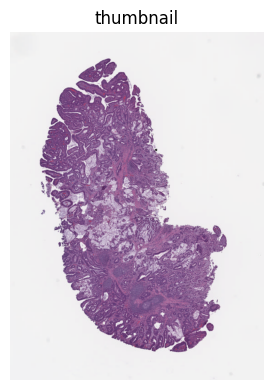

In [6]:
# Affichage des images associées
fig, axes = plt.subplots(1, len(slide.associated_images), figsize=(15, 4))
if len(slide.associated_images) == 1:
    axes = [axes]
for ax, (name, img) in zip(axes, slide.associated_images.items()):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Extraction de tuiles au niveau 0

On extrait quelques tuiles de la pleine résolution pour voir ce que contient réellement le fichier.

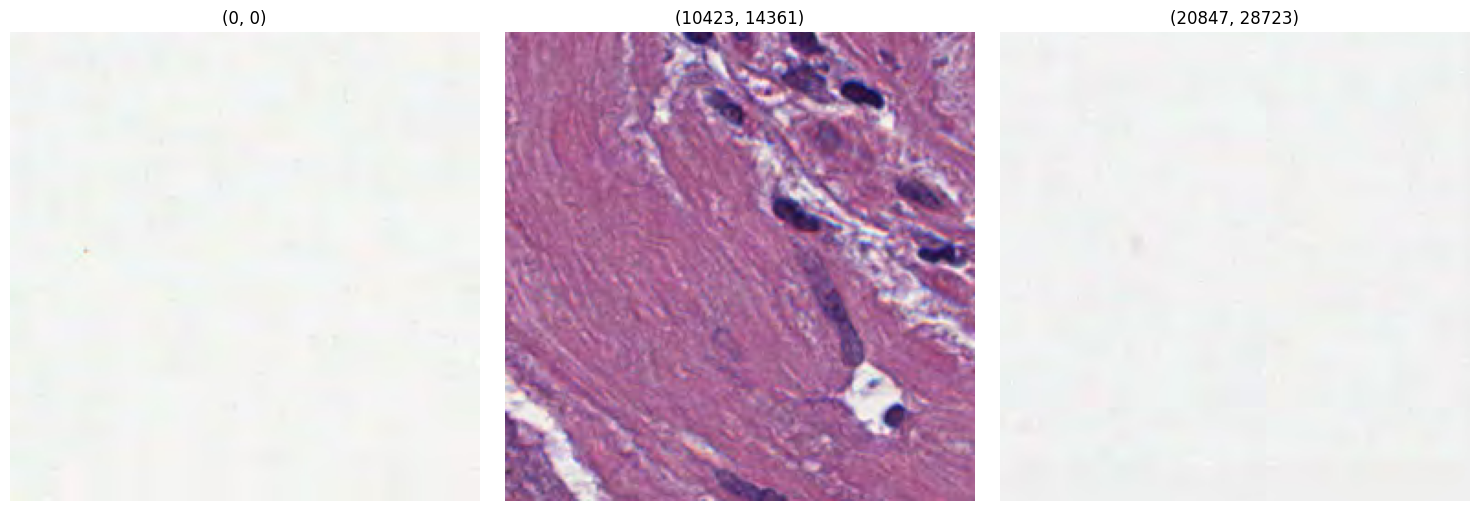

In [7]:
LEVEL = 0
TILE_SIZE = 256  # taille standard

w0, h0 = slide.level_dimensions[0]

# Quelques positions de tuiles : coin haut-gauche, centre, coin bas-droite
positions = [
    (0, 0),                          # coin haut-gauche
    (w0 // 2 - TILE_SIZE // 2, h0 // 2 - TILE_SIZE // 2),  # centre
    (w0 - TILE_SIZE, h0 - TILE_SIZE), # coin bas-droite
]

fig, axes = plt.subplots(1, len(positions), figsize=(15, 5))
for ax, (x, y) in zip(axes, positions):
    tile = slide.read_region((x, y), LEVEL, (TILE_SIZE, TILE_SIZE)).convert("RGB")
    ax.imshow(tile)
    ax.set_title(f"({x}, {y})")
    ax.axis("off")
    # Sauvegarde
    tile.save(OUT_DIR / f"{SVS_PATH.stem}_tile_{x}_{y}.png")
plt.tight_layout()
plt.show()

## 4. Premières expérimentations de compression

On prend une région de l'image (ex. 2048×2048 au niveau 0), on la compresse en JPEG à différents quality levels, et on mesure :
- Taille du fichier
- SSIM (similarité structurale) par rapport à l'original

In [8]:
# Paramètres de la région à tester
REGION_SIZE = 2048
LOCATION = (w0 // 2 - REGION_SIZE // 2, h0 // 2 - REGION_SIZE // 2)  # centre de la lame

# Extraction de la région
region = slide.read_region(LOCATION, LEVEL, (REGION_SIZE, REGION_SIZE)).convert("RGB")
region_arr = np.array(region)
print(f"Région extraite : {region_arr.shape}")

# Sauvegarde de référence sans perte (PNG)
ref_path = OUT_DIR / "region_ref.png"
region.save(ref_path, format="PNG")
print(f"Référence PNG : {ref_path.stat().st_size / 1024:.1f} Ko")

Région extraite : (2048, 2048, 3)
Référence PNG : 9430.1 Ko


In [9]:
from skimage.metrics import structural_similarity as ssim

qualities = [95, 85, 75, 65, 55, 45, 35]
results = []

ref_float = region_arr.astype(np.float32) / 255.0

for q in qualities:
    out_path = OUT_DIR / f"region_jpeg_q{q}.jpg"
    region.save(out_path, format="JPEG", quality=q, optimize=True)
    
    # Lecture et calcul SSIM
    rec = np.array(Image.open(out_path).convert("RGB")).astype(np.float32) / 255.0
    s = ssim(ref_float, rec, channel_axis=2, data_range=1.0)
    
    size_kb = out_path.stat().st_size / 1024
    results.append((q, size_kb, s))
    print(f"JPEG Q={q:3d} | {size_kb:8.1f} Ko | SSIM={s:.4f}")

JPEG Q= 95 |   2071.0 Ko | SSIM=0.9716
JPEG Q= 85 |   1188.2 Ko | SSIM=0.9468
JPEG Q= 75 |    897.5 Ko | SSIM=0.9324
JPEG Q= 65 |    752.7 Ko | SSIM=0.9222
JPEG Q= 55 |    651.6 Ko | SSIM=0.9130
JPEG Q= 45 |    577.8 Ko | SSIM=0.9041
JPEG Q= 35 |    494.6 Ko | SSIM=0.8915


,Qualité,Taille (Ko),SSIM,Ratio vs PNG
0,95,2071.013672,0.971643,0.22
1,85,1188.159180,0.946769,0.13
2,75,897.487305,0.932358,0.10
3,65,752.719727,0.922167,0.08
4,55,651.575195,0.913008,0.07
5,45,577.780273,0.904099,0.06
6,35,494.583008,0.891467,0.05


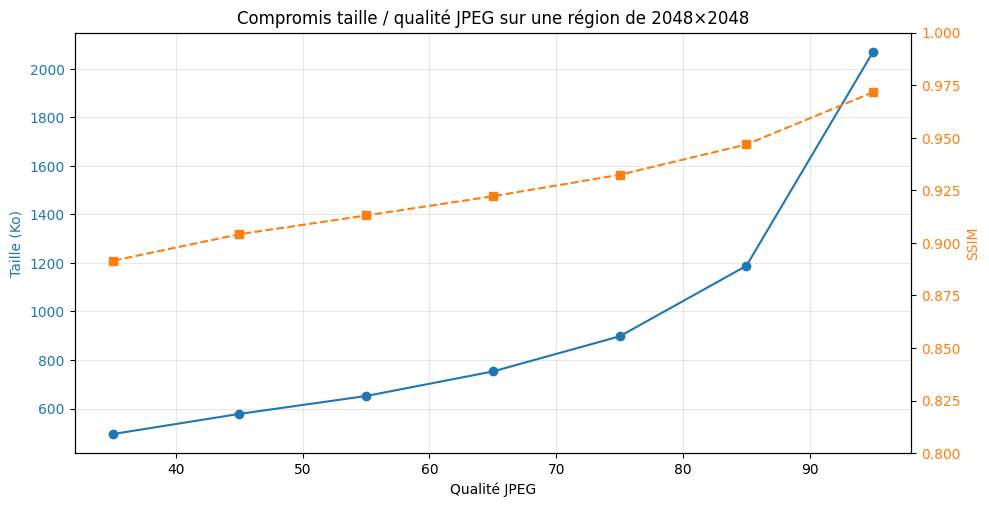

In [11]:
# Tableau récapitulatif
import pandas as pd

df = pd.DataFrame(results, columns=["Qualité", "Taille (Ko)", "SSIM"])
df["Ratio vs PNG"] = (df["Taille (Ko)"] / (ref_path.stat().st_size / 1024)).round(2)
display(df)

# Graphique taille vs SSIM
fig, ax1 = plt.subplots(figsize=(10, 5))

color = "tab:blue"
ax1.set_xlabel("Qualité JPEG")
ax1.set_ylabel("Taille (Ko)", color=color)
ax1.plot(df["Qualité"], df["Taille (Ko)"], "o-", color=color, label="Taille")
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("SSIM", color=color)
ax2.plot(df["Qualité"], df["SSIM"], "s--", color=color, label="SSIM")
ax2.tick_params(axis="y", labelcolor=color)
ax2.set_ylim(0.8, 1.0)

fig.tight_layout()
plt.title("Compromis taille / qualité JPEG sur une région de 2048×2048")
plt.show()

## 5. Analyse du fond blanc

Idée simple : estimer la proportion de fond blanc sur la vignette basse résolution.

In [12]:
# On prend le dernier niveau (le plus petit) pour la segmentation rapide
last_level = slide.level_count - 1
thumb_w, thumb_h = slide.level_dimensions[last_level]
thumb = slide.read_region((0, 0), last_level, (thumb_w, thumb_h)).convert("RGB")
thumb_arr = np.array(thumb)

print(f"Vignette niveau {last_level} : {thumb_arr.shape}")

# Segmentation simple : fond = pixels très clairs (R,G,B > 200)
mask_white = (thumb_arr[:,:,0] >= 200) & (thumb_arr[:,:,1] >= 200) & (thumb_arr[:,:,2] >= 200)

# Ou zone grise (pas de tissu)
rgb_max = thumb_arr.max(axis=2)
rgb_min = thumb_arr.min(axis=2)
mask_gray = (rgb_max - rgb_min) <= 15

mask_background = mask_white | mask_gray
mask_tissue = ~mask_background

tissue_pct = mask_tissue.sum() / mask_tissue.size * 100
print(f"\nTissu détecté : {tissue_pct:.1f}%")
print(f"Fond détecté : {100 - tissue_pct:.1f}%")

Vignette niveau 2 : (1811, 1318, 3)

Tissu détecté : 33.2%
Fond détecté : 66.8%


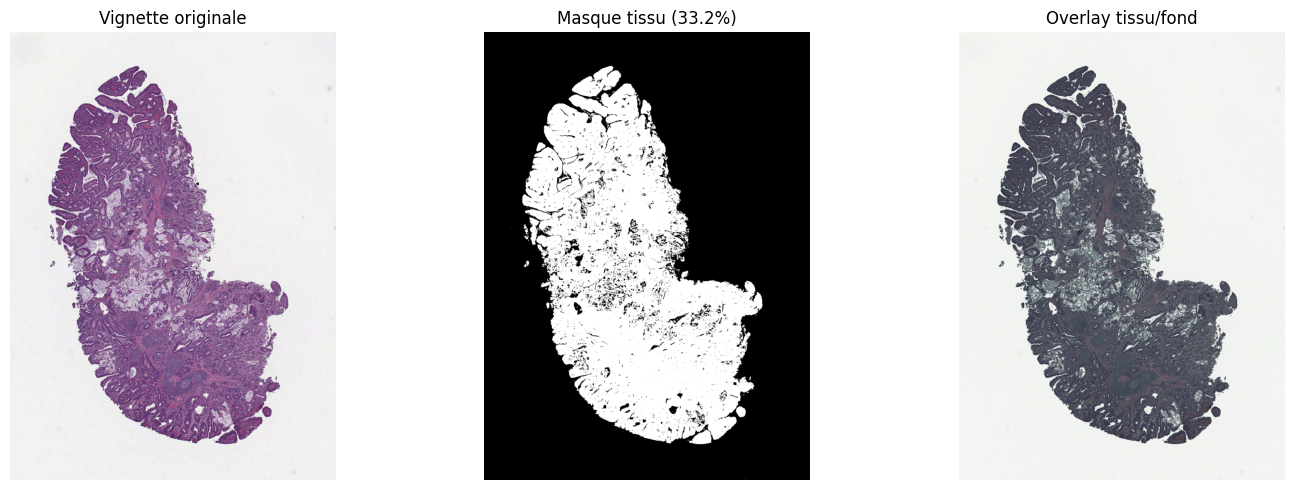

In [13]:
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(thumb_arr)
axes[0].set_title("Vignette originale")
axes[0].axis("off")

axes[1].imshow(mask_tissue, cmap="gray")
axes[1].set_title(f"Masque tissu ({tissue_pct:.1f}%)")
axes[1].axis("off")

axes[2].imshow(thumb_arr)
axes[2].imshow(mask_tissue, cmap="Greens", alpha=0.4)
axes[2].set_title("Overlay tissu/fond")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 6. Fermeture

In [16]:
slide.close()

ArgumentError: argument 1: ValueError: Passing closed slide object